In [5]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx

# ── Definir o grafo ───────────────────────────────────────────────────────────
G = nx.DiGraph()  # DiGraph = Directed Graph

# Adicionar nós com atributo de perspectiva
nodes = {
    "A1": "Aprendizado",
    "A2": "Aprendizado",
    "P1": "Processos",
    "P2": "Processos",
    "C1": "Clientes",
    "C2": "Clientes",
    "F1": "Financeiro",
    "F2": "Financeiro",
}
for node, persp in nodes.items():
    G.add_node(node, perspectiva=persp)

# Adicionar arestas (sem peso por enquanto)
edges = [
    ("A1", "P1"),
    ("A2", "P1"),
    ("P1", "P2"),
    ("P1", "C1"),
    ("P2", "C1"),
    ("C1", "C2"),
    ("C2", "F1"),
    ("P1", "F1"),
    ("F1", "F2"),
]
G.add_edges_from(edges)

In [6]:
# ── Layout por perspectiva (posições fixas) ───────────────────────────────────
pos = {
    "A1": (0, 2),
    "A2": (0, 0),  # coluna 0 — Aprendizado
    "P1": (2, 1),
    "P2": (3, 0),  # coluna 2-3 — Processos
    "C1": (4, 2),
    "C2": (5, 1),  # coluna 4-5 — Clientes
    "F1": (7, 2),
    "F2": (7, 0),  # coluna 7 — Financeiro
}

# ── Cores por perspectiva ─────────────────────────────────────────────────────
color_map = {
    "Aprendizado": "#3b82f6",
    "Processos": "#8b5cf6",
    "Clientes": "#10b981",
    "Financeiro": "#f59e0b",
}
node_colors = [color_map[nodes[n]] for n in G.nodes()]


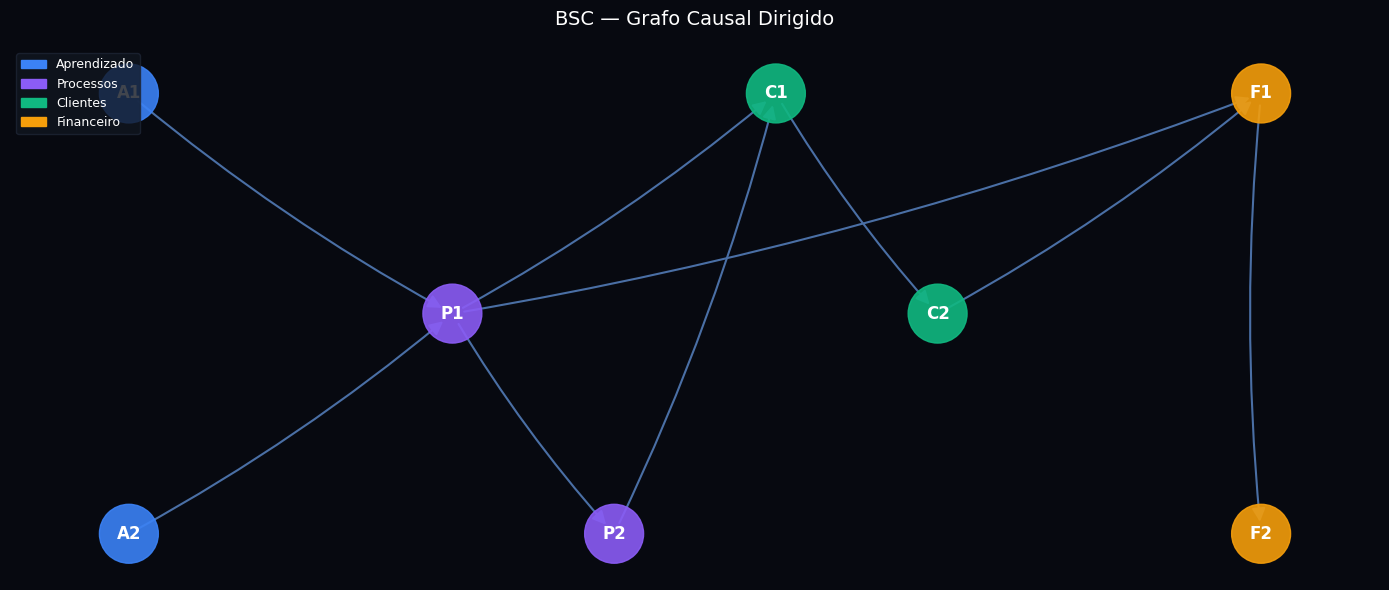

In [7]:
# ── Visualização ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#070910")
ax.set_facecolor("#0d1017")

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, alpha=0.9, ax=ax)

nx.draw_networkx_labels(
    G, pos, font_color="white", font_size=12, font_weight="bold", ax=ax
)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color="#4a6fa5",
    arrows=True,
    arrowsize=20,
    width=1.5,
    ax=ax,
    connectionstyle="arc3,rad=0.05",
)

# Legenda
legend_handles = [mpatches.Patch(color=c, label=p) for p, c in color_map.items()]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    facecolor="#111620",
    edgecolor="#1e2535",
    labelcolor="white",
    fontsize=9,
)

ax.set_title("BSC — Grafo Causal Dirigido", color="white", fontsize=14, pad=16)
ax.axis("off")
plt.tight_layout()
plt.show()
